# 41 — Implement entire MotionSense-AI Project in one complete pipeline

## Goal
To run the entire machine learning workflow from raw data cleaning to final model evaluation.

## Research Question
Can smartphone sensor data predict human activity using a complete machine learning pipeline?

## MotionSense-AI Pipeline

```text
Raw Data → Clean Data → Features → Machine Learning → Prediction
```

This notebook completes the **entire pipeline in one place**.

## Complete project workflow:


```text
→ Load Raw Data
→ Inspect Target
→ Clean Missing Values
→ Remove Duplicates
→ Engineer Features
→ Save Processed Data
→ Select Features
→ Split Data
→ Train Model
→ Predict
→ Evaluate
→ Save Model
```

In [11]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# All notebooks use the same shared data folder.
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
RAW_PATH = PROCESSED_DIR / "motionsense_raw_better_accuracy.csv"

CLEAN_PATH = PROCESSED_DIR / "motionsense_clean.csv"
ML_READY_PATH = PROCESSED_DIR / "motionsense_ml_ready.csv"
FINAL_MODEL_PATH = PROCESSED_DIR / "motionsense_final_model.joblib"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Part 1 — Load and inspect the raw data

We begin with the raw smartphone sensor dataset.

In [12]:
# 1. Load raw data.
df = pd.read_csv(RAW_PATH)

print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (4320, 11)


,row_id,subject,time_step,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,device
0,1,1,0,Walking,-1.366238,0.141533,9.407383,0.110981,-0.215429,0.080877,phone_A
1,2,1,1,Walking,-0.923150,0.618553,9.569189,0.333847,-0.201017,0.162930,phone_A
2,3,1,2,Walking,-0.443748,0.811328,9.791356,0.507663,-0.047909,0.151096,phone_A
3,4,1,3,Walking,0.298202,0.936214,10.093388,0.509257,0.133485,0.188788,phone_A
4,5,1,4,Walking,0.985163,0.605370,10.049109,0.398746,0.299541,0.066716,phone_A


In [13]:
# 2. Inspect the target column.
print(df["activity"].value_counts())

activity
Walking               720
Walking Upstairs      720
Walking Downstairs    720
Sitting               720
Standing              720
Laying                720
Name: count, dtype: int64


## Part 2 — Clean the raw data

The cleaning logic used as follows:

- create a safe working copy
- standardize activity text
- convert sensor columns to numeric values
- fill missing sensor values with column means
- remove duplicate rows.

In [14]:
# 3. Create a clean working copy.
clean_df = df.copy()

# Standardize text in the activity column.
clean_df["activity"] = clean_df["activity"].str.strip()

# Fill missing sensor values with each column mean.
sensor_columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

for column in sensor_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")
    clean_df[column] = clean_df[column].fillna(clean_df[column].mean())

# Remove duplicate rows and reset row numbers.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Clean dataset shape:", clean_df.shape)
print("Missing values remaining:", clean_df[sensor_columns].isna().sum().sum())
clean_df.head()

Clean dataset shape: (4320, 11)
Missing values remaining: 0


,row_id,subject,time_step,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,device
0,1,1,0,Walking,-1.366238,0.141533,9.407383,0.110981,-0.215429,0.080877,phone_A
1,2,1,1,Walking,-0.923150,0.618553,9.569189,0.333847,-0.201017,0.162930,phone_A
2,3,1,2,Walking,-0.443748,0.811328,9.791356,0.507663,-0.047909,0.151096,phone_A
3,4,1,3,Walking,0.298202,0.936214,10.093388,0.509257,0.133485,0.188788,phone_A
4,5,1,4,Walking,0.985163,0.605370,10.049109,0.398746,0.299541,0.066716,phone_A


## Part 3 — Feature engineering

Magnitude combines movement across the three sensor axes into one useful value.

```text
magnitude = square root of (x² + y² + z²)
```

In [15]:
# 4. Create magnitude features.
clean_df["acc_magnitude"] = np.sqrt(
    clean_df["acc_x"]**2
    + clean_df["acc_y"]**2
    + clean_df["acc_z"]**2
)

clean_df["gyro_magnitude"] = np.sqrt(
    clean_df["gyro_x"]**2
    + clean_df["gyro_y"]**2
    + clean_df["gyro_z"]**2
)

clean_df[["activity", "acc_magnitude", "gyro_magnitude"]].head()

,activity,acc_magnitude,gyro_magnitude
0,Walking,9.507129,0.255475
1,Walking,9.633493,0.422383
2,Walking,9.834929,0.531834
3,Walking,10.141099,0.559287
4,Walking,10.115414,0.503164


In [16]:
# 5. Create an ML-ready copy with an activity code.
ml_ready_df = clean_df.copy()

activity_map = {
    activity: code
    for code, activity in enumerate(sorted(ml_ready_df["activity"].unique()))
}

ml_ready_df["activity_code"] = ml_ready_df["activity"].map(activity_map)

print(activity_map)
ml_ready_df.head()

{'Laying': 0, 'Sitting': 1, 'Standing': 2, 'Walking': 3, 'Walking Downstairs': 4, 'Walking Upstairs': 5}


,row_id,subject,time_step,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,device,acc_magnitude,gyro_magnitude,activity_code
0,1,1,0,Walking,-1.366238,0.141533,9.407383,0.110981,-0.215429,0.080877,phone_A,9.507129,0.255475,3
1,2,1,1,Walking,-0.923150,0.618553,9.569189,0.333847,-0.201017,0.162930,phone_A,9.633493,0.422383,3
2,3,1,2,Walking,-0.443748,0.811328,9.791356,0.507663,-0.047909,0.151096,phone_A,9.834929,0.531834,3
3,4,1,3,Walking,0.298202,0.936214,10.093388,0.509257,0.133485,0.188788,phone_A,10.141099,0.559287,3
4,5,1,4,Walking,0.985163,0.605370,10.049109,0.398746,0.299541,0.066716,phone_A,10.115414,0.503164,3


In [17]:
# 6. Export clean and ML-ready datasets.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(CLEAN_PATH, index=False)
ml_ready_df.to_csv(ML_READY_PATH, index=False)

print("Saved clean dataset to:", CLEAN_PATH)
print("Saved ML-ready dataset to:", ML_READY_PATH)

Saved clean dataset to: ../data/processed/motionsense_clean.csv
Saved ML-ready dataset to: ../data/processed/motionsense_ml_ready.csv


## Part 4 — Build the machine learning model

Now the processed data is ready for the complete machine learning workflow.

In [18]:
# 7. Select the feature set.
feature_columns = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_magnitude", "gyro_magnitude"
]

X = ml_ready_df[feature_columns]
y = ml_ready_df["activity"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4320, 8)
Target shape: (4320,)


In [19]:
# 8. Split the data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3456
Testing rows: 864


In [20]:
# 9. Train the model.
model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [21]:
# 10. Make predictions.
predictions = model.predict(X_test)

# 11. Evaluate accuracy.
accuracy = accuracy_score(y_test, predictions)
print(f"Final accuracy: {accuracy:.2%}")

Final accuracy: 99.07%


In [22]:
# Show detailed performance by activity.
print(classification_report(y_test, predictions))

                    precision    recall  f1-score   support

            Laying       1.00      1.00      1.00       144
           Sitting       1.00      1.00      1.00       144
          Standing       1.00      1.00      1.00       144
           Walking       0.95      1.00      0.97       144
Walking Downstairs       1.00      0.98      0.99       144
  Walking Upstairs       1.00      0.97      0.98       144

          accuracy                           0.99       864
         macro avg       0.99      0.99      0.99       864
      weighted avg       0.99      0.99      0.99       864



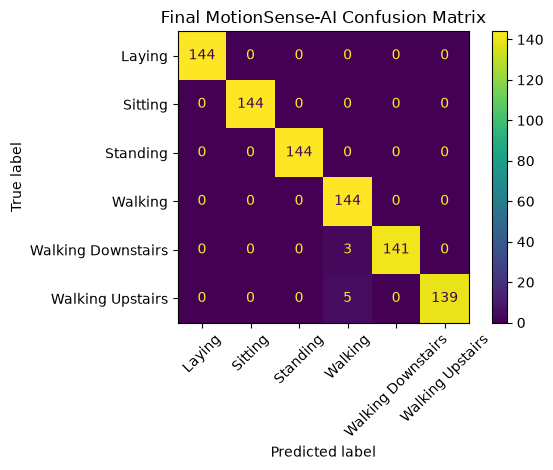

In [23]:
# Visualize prediction mistakes.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)

plt.title("Final MotionSense-AI Confusion Matrix")
plt.tight_layout()
plt.show()

gyro_magnitude    0.224064
acc_x             0.206261
acc_z             0.161190
acc_y             0.128807
gyro_x            0.081053
acc_magnitude     0.067864
gyro_z            0.066729
gyro_y            0.064032
dtype: float64


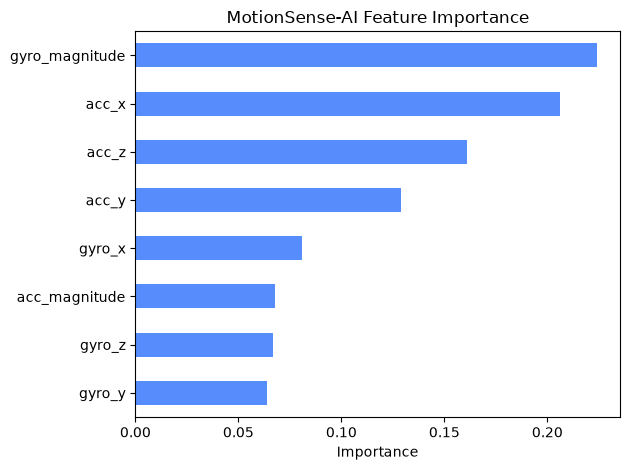

In [24]:
# 12. Show feature importance.
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print(feature_importance)

feature_importance.sort_values().plot(kind="barh")
plt.title("MotionSense-AI Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
# 13. Save the final model.
joblib.dump(model, FINAL_MODEL_PATH)

print("Final model saved to:", FINAL_MODEL_PATH)
print("Clean data saved to:", CLEAN_PATH)
print("ML-ready data saved to:", ML_READY_PATH)

Final model saved to: ../data/processed/motionsense_final_model.joblib
Clean data saved to: ../data/processed/motionsense_clean.csv
ML-ready data saved to: ../data/processed/motionsense_ml_ready.csv


## Final research conclusion

The notebook begins with raw smartphone sensor measurements, cleans the data, creates engineered motion features, trains a Random Forest model, evaluates its predictions, and saves all final outputs.

This completes the full MotionSense-AI pipeline:

```text
Raw Data → Clean Data → Engineered Features → Trained Model → Predictions
```


## Summary

This notebook combines data cleaning, feature engineering, model training, prediction, evaluation, and model saving into one complete machine learning pipeline.